<a href="https://colab.research.google.com/github/Alex-del-25/meu-primeiro-projeto/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primeiras 5 linhas do DataFrame:


,id_venda,data_venda,produto,categoria,valor_venda
0,1,2023-01-01,Produto A,Eletrônicos,1500.0
1,2,2023-01-05,Produto B,Roupas,350.0
2,3,2023-02-10,Produto C,Eletrônicos,1200.0
3,4,2023-03-15,Produto D,Livros,200.0
4,5,2023-03-20,Produto E,Eletrônicos,800.0



Informações básicas do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     168 non-null    int64  
 1   data_venda   168 non-null    object 
 2   produto      168 non-null    object 
 3   categoria    168 non-null    object 
 4   valor_venda  168 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 6.7+ KB
Tipos de dados após conversão de 'data_venda':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     168 non-null    int64         
 1   data_venda   168 non-null    datetime64[ns]
 2   produto      168 non-null    object        
 3   categoria    168 non-null    object        
 4   valor_venda  168 non-null    float64       
dtypes: dat

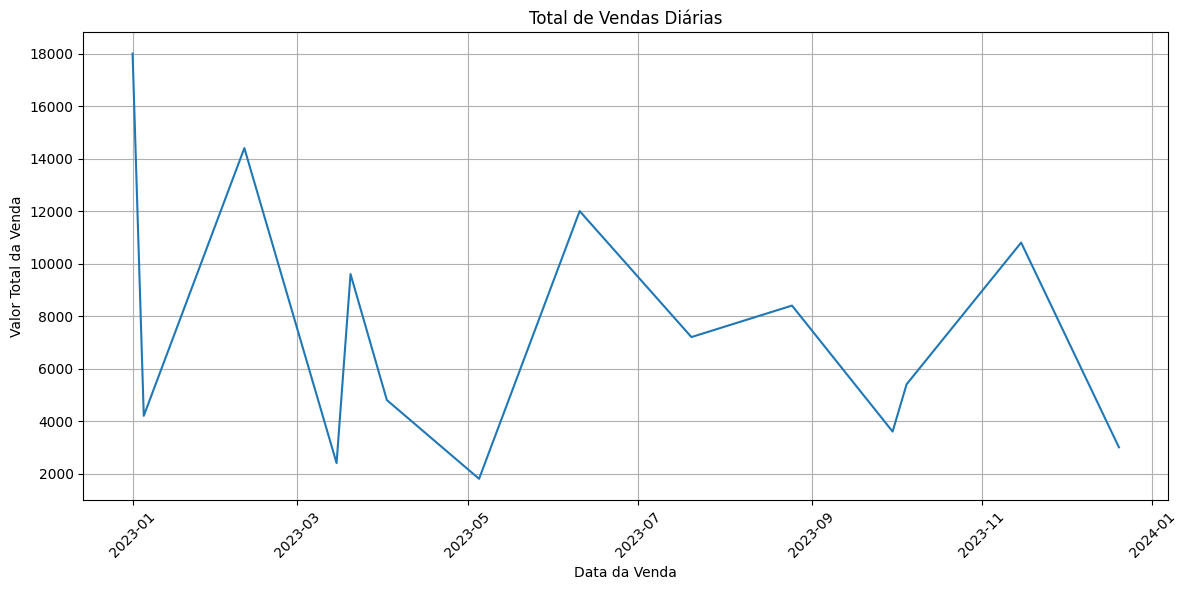

/tmp/ipykernel_11941/2426131248.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='valor_venda', data=vendas_por_categoria, palette='viridis')


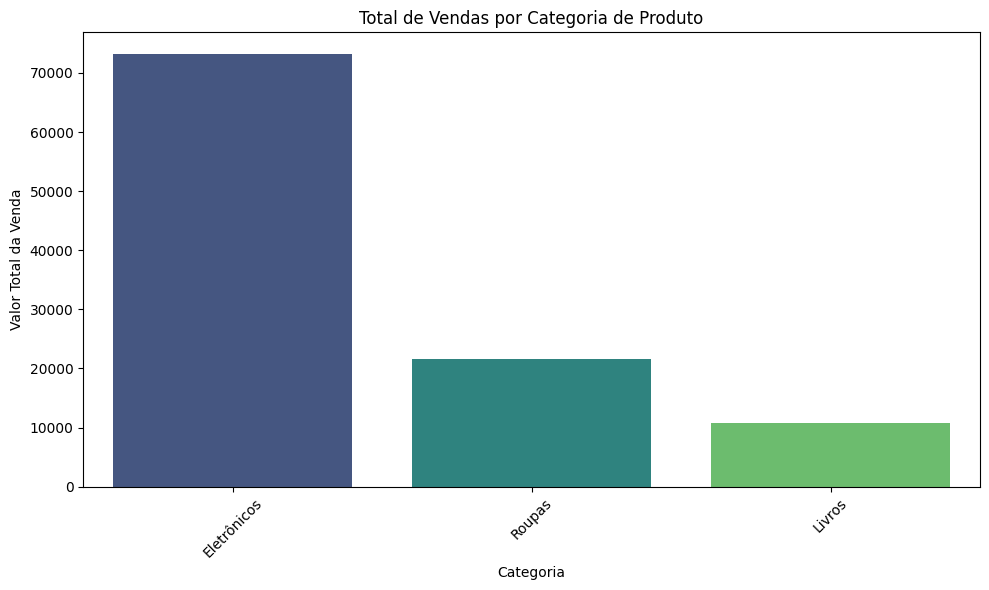

In [64]:
#Conectar ao banco de dados SQLite e criar uma tabela
import sqlite3
conexao = sqlite3.connect('dados_venda.db')


#Criar um cursor
cursor = conexao.cursor()

#Criar uma tabela
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
  id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
  data_venda DATE,
  produto TEXT,
  categoria TEXT,
  valor_venda REAL

)
''')

#Inserir alguns dados
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
''')

# Confirmar as alterações
conexao.commit()

# Fechar a conexão
conexao.close()

 #Explorar e preparar os dados
import pandas as pd
import sqlite3

# Conectar ao banco de dados
conexao = sqlite3.connect('dados_venda.db')

# Carregar os dados da tabela 'vendas1' em um DataFrame do Pandas
df_vendas = pd.read_sql_query('SELECT *FROM vendas1', conexao)

# Fechar a conexão com o banco de dados
conexao.close()

# Exibir as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas do DataFrame:")
display(df_vendas.head())

# Exibir informações básicas sobre o DataFrame (tipos de dados, valores não nulos)
print("\nInformações básicas do DataFrame:")
df_vendas.info()


import matplotlib.pyplot as plt
import seaborn as sns

# Converter a coluna 'data_venda' para o tipo datetime
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

# Verificar os tipos de dados após a conversão
print("Tipos de dados após conversão de 'data_venda':")
df_vendas.info()


# Calcular o total de vendas diárias
vendas_diarias = df_vendas.groupby('data_venda')['valor_venda'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='data_venda', y='valor_venda', data=vendas_diarias)
plt.title('Total de Vendas Diárias')
plt.xlabel('Data da Venda')
plt.ylabel('Valor Total da Venda')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calcular o total de vendas por categoria
vendas_por_categoria = df_vendas.groupby('categoria')['valor_venda'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='categoria', y='valor_venda', data=vendas_por_categoria, palette='viridis')
plt.title('Total de Vendas por Categoria de Produto')
plt.xlabel('Categoria')
plt.ylabel('Valor Total da Venda')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
